# 🎗️ Breast Cancer Prediction — Comparative Study
### Mohammed EL-ASYOUTE

**Dataset:** Wisconsin Breast Cancer Dataset (`breastCancer.csv`)  
**Target:** `diagnosis` — **M** (Malignant) or **B** (Benign)  
**Algorithms compared:**
1. Logistic Regression
2. Support Vector Machine (SVM)
3. K-Nearest Neighbours (KNN)
4. K-Means Clustering (unsupervised)
5. Decision Tree — ID3 Algorithm

---

## 1 · Imports & Configuration

In [9]:
# ── Standard library ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Pre-processing ────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# ── Algorithms ────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ── Evaluation ────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# ── Styling ───────────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
SEED   = 42

print('✅  All imports successful.')

✅  All imports successful.


---
## 2 · Data Loading & Initial Exploration

In [10]:
df = pd.read_csv('breastCancer.csv')
print(f'Shape: {df.shape}  →  {df.shape[0]} samples, {df.shape[1]} columns')
df.head()

Shape: (569, 33)  →  569 samples, 33 columns


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [11]:
print('─── Column dtypes & non-null counts ───')
df.info()

─── Column dtypes & non-null counts ───
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null   

In [12]:
print('─── Statistical Summary ───')
df.describe().T.style.background_gradient(cmap='Blues')

─── Statistical Summary ───


,count,mean,std,min,25%,50%,75%,max
id,569.000000,30371831.432337,125020585.612224,8670.000000,869218.000000,906024.000000,8813129.000000,911320502.000000
radius_mean,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
texture_mean,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
perimeter_mean,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
area_mean,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
smoothness_mean,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
compactness_mean,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
concavity_mean,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
concave points_mean,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
symmetry_mean,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000


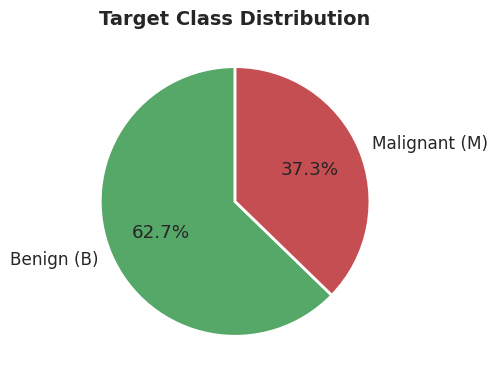

diagnosis
B    357
M    212
Name: count, dtype: int64


In [13]:
# Class distribution
fig, ax = plt.subplots(figsize=(5, 4))
cnt = df['diagnosis'].value_counts()
ax.pie(cnt, labels=['Benign (B)', 'Malignant (M)'],
       autopct='%1.1f%%', colors=['#55A868', '#C44E52'],
       startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Target Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(cnt)

---
## 3 · Data Preprocessing

### 3.1 · Drop Irrelevant Columns & Check Missing Values

In [14]:
# 'id' is a patient identifier — not a feature
df.drop(columns=['id'], inplace=True)

# Check for any unnamed trailing column (common in this dataset)
unnamed_cols = [c for c in df.columns if 'Unnamed' in c]
if unnamed_cols:
    df.drop(columns=unnamed_cols, inplace=True)
    print(f'Dropped unnamed columns: {unnamed_cols}')

# Missing values
missing = df.isnull().sum()
print('\nMissing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values ✅')

Dropped unnamed columns: ['Unnamed: 32']

Missing values per column:
No missing values ✅


### 3.2 · Encode Target Variable

In [15]:
# M → 1 (Malignant / positive class)  |  B → 0 (Benign)
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])   # B=0, M=1
print('Encoding:', dict(zip(le.classes_, le.transform(le.classes_))))
print('Value counts after encoding:')
print(df['diagnosis'].value_counts())

Encoding: {'B': np.int64(0), 'M': np.int64(1)}
Value counts after encoding:
diagnosis
0    357
1    212
Name: count, dtype: int64


### 3.3 · Feature/Target Split

In [16]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Feature names  : {list(X.columns)}')

Features shape : (569, 30)
Target shape   : (569,)
Feature names  : ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


### 3.4 · Correlation Heatmap (Feature Exploration)

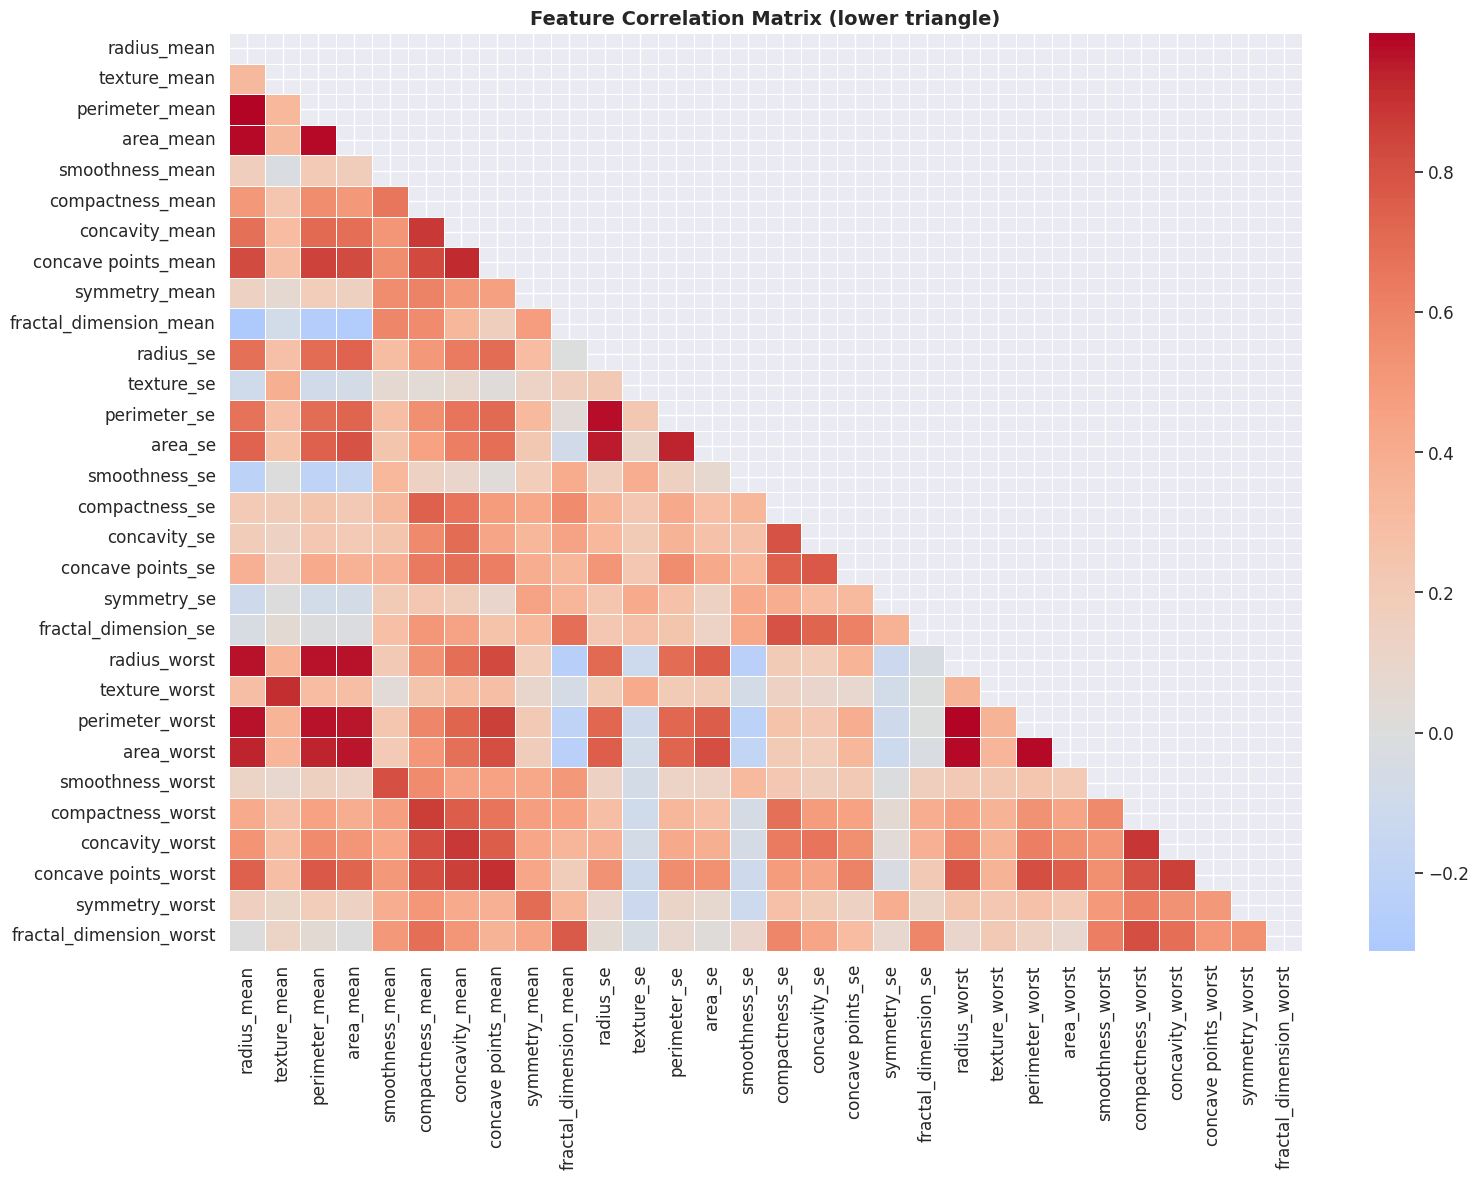

In [17]:
fig, ax = plt.subplots(figsize=(16, 12))
corr_matrix = X.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # upper triangle
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix (lower triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 · Feature Scaling & Train/Test Split

In [18]:
# Split BEFORE scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Standard scaling (z-score normalisation)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train, transform train
X_test_sc  = scaler.transform(X_test)        # transform test using train stats

print(f'Training set : {X_train_sc.shape[0]} samples')
print(f'Test set     : {X_test_sc.shape[0]} samples')
print(f'Train pos/neg: {y_train.sum()} / {(y_train==0).sum()}')
print(f'Test  pos/neg: {y_test.sum()}  / {(y_test==0).sum()}')

Training set : 455 samples
Test set     : 114 samples
Train pos/neg: 170 / 285
Test  pos/neg: 42  / 72


### 3.6 · Boxplots — Scaled Feature Distribution by Class

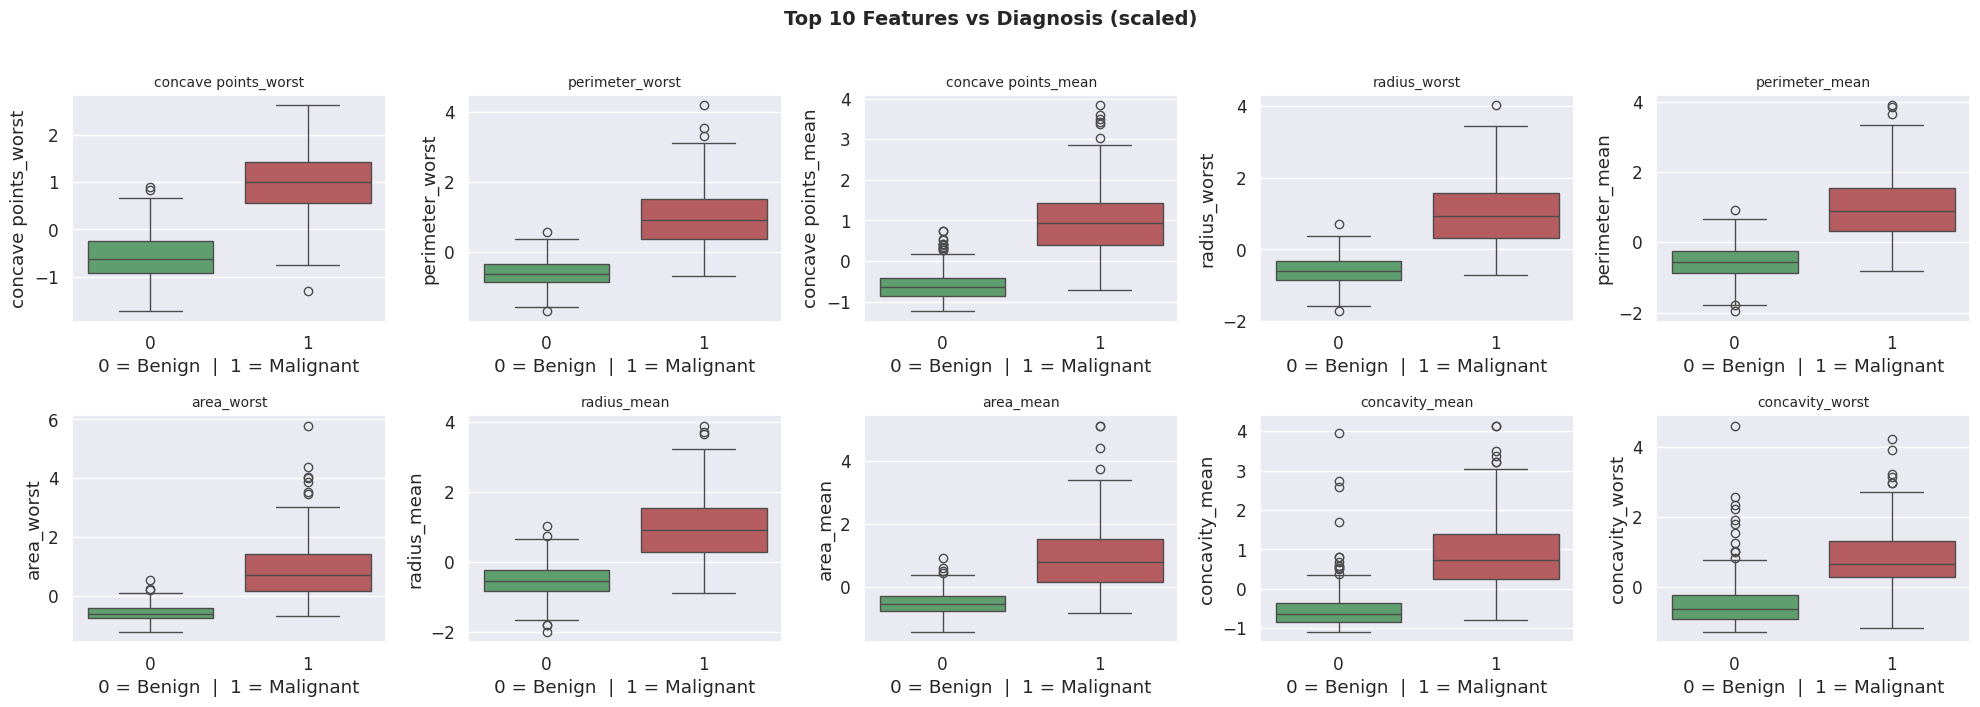

In [19]:
df_scaled = pd.DataFrame(X_train_sc, columns=X.columns)
df_scaled['diagnosis'] = y_train.values

# Show the 10 most correlated features with diagnosis
top_feats = X.corrwith(y).abs().nlargest(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()
for i, feat in enumerate(top_feats):
    sns.boxplot(data=df_scaled, x='diagnosis', y=feat,
                palette=['#55A868', '#C44E52'], ax=axes[i])
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('0 = Benign  |  1 = Malignant')
plt.suptitle('Top 10 Features vs Diagnosis (scaled)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4 · Helper Utilities

In [20]:
results = {}   # store each model's metrics here

def evaluate(name, model, X_tr, y_tr, X_te, y_te, proba=True):
    """Fit model, compute metrics, store results and render confusion matrix."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, model.predict_proba(X_te)[:,1]) if proba else np.nan
    cv   = cross_val_score(model, X_tr, y_tr, cv=StratifiedKFold(5), scoring='accuracy').mean()

    results[name] = {'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1': f1,
                     'ROC-AUC': auc, 'CV-Accuracy': cv}

    # Print report
    print(f'\n══════════════════════  {name}  ══════════════════════')
    print(classification_report(y_te, y_pred, target_names=['Benign','Malignant']))
    print(f'  ROC-AUC   : {auc:.4f}' if proba else '  ROC-AUC   : N/A (no predict_proba)')
    print(f'  CV-Acc(5) : {cv:.4f}')

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(4, 3.5))
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=['Benign','Malignant'],
        colorbar=False, ax=ax, cmap='Blues'
    )
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return model, y_pred

print('✅  Helper defined.')

✅  Helper defined.


---
## 5 · Algorithm 1 — Logistic Regression


══════════════════════  Logistic Regression  ══════════════════════
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

  ROC-AUC   : 0.9960
  CV-Acc(5) : 0.9714


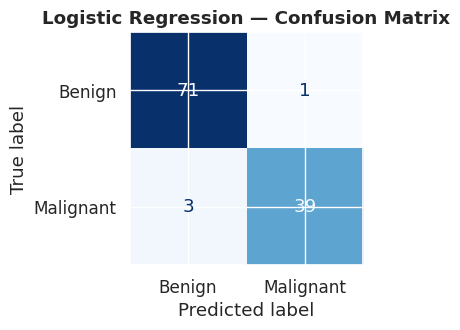

In [21]:
lr_model, lr_pred = evaluate(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=SEED),
    X_train_sc, y_train, X_test_sc, y_test
)

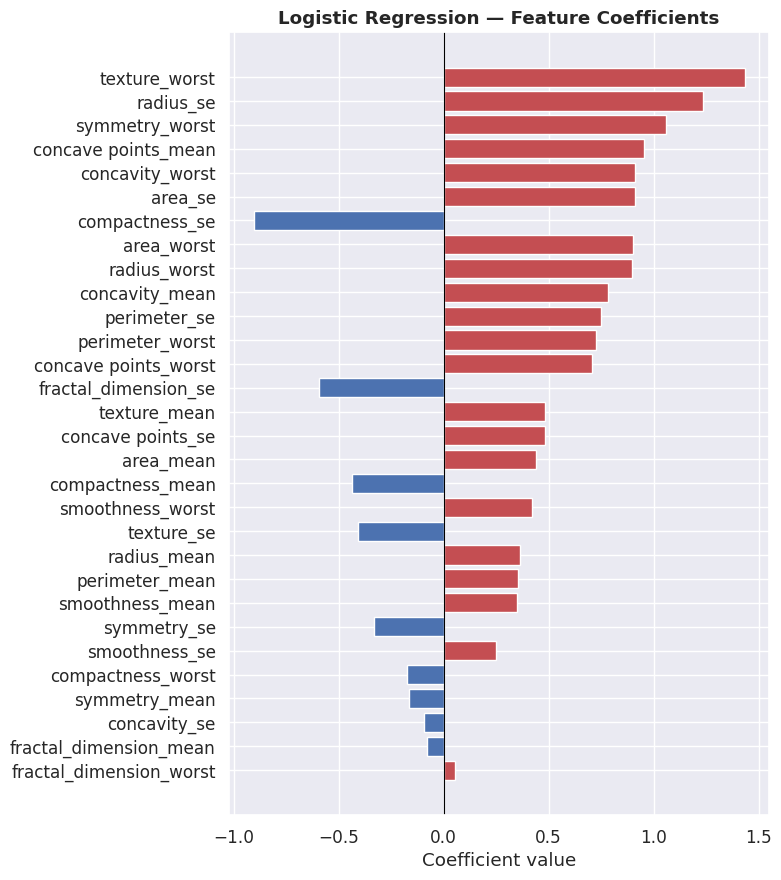

In [22]:
# Feature coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=True).index)

fig, ax = plt.subplots(figsize=(8, 9))
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'],
               color=['#C44E52' if v > 0 else '#4C72B0' for v in coef_df['Coefficient']])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Feature Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

---
## 6 · Algorithm 2 — Support Vector Machine (SVM)


══════════════════════  SVM  ══════════════════════
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

  ROC-AUC   : 0.9947
  CV-Acc(5) : 0.9758


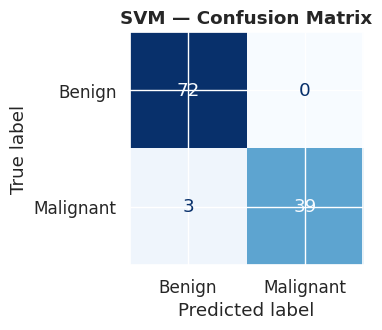

In [23]:
svm_model, svm_pred = evaluate(
    'SVM',
    SVC(kernel='rbf', probability=True, random_state=SEED, C=1.0, gamma='scale'),
    X_train_sc, y_train, X_test_sc, y_test
)

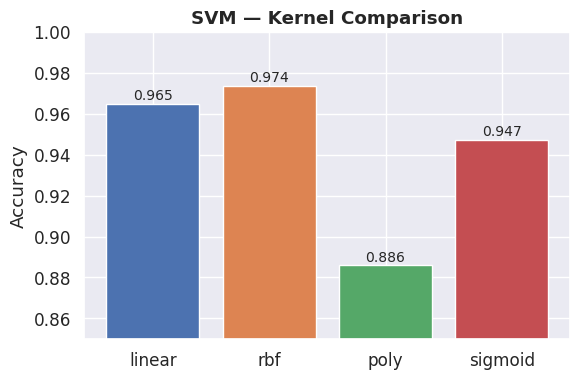

In [24]:
# Kernel comparison (visual)
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
k_accs  = []
for k in kernels:
    m = SVC(kernel=k, probability=True, random_state=SEED)
    m.fit(X_train_sc, y_train)
    k_accs.append(accuracy_score(y_test, m.predict(X_test_sc)))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(kernels, k_accs, color=COLORS[:4])
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('SVM — Kernel Comparison', fontweight='bold')
for rect, val in zip(ax.patches, k_accs):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.002,
            f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 7 · Algorithm 3 — K-Nearest Neighbours (KNN)

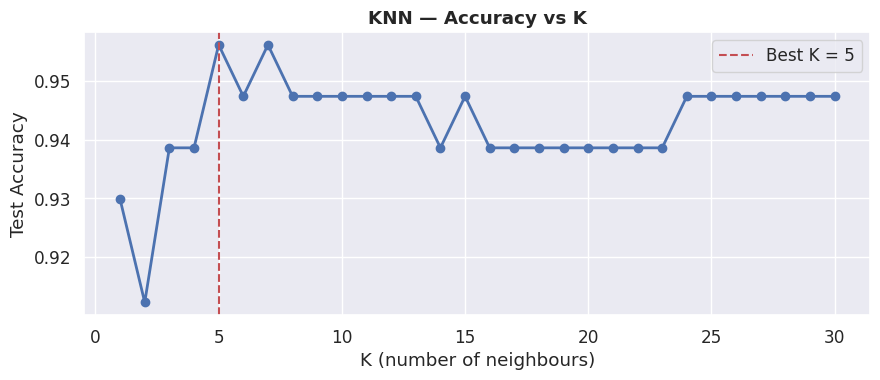

Best K: 5  |  Accuracy: 0.9561


In [25]:
# Find optimal K
k_range  = range(1, 31)
k_scores = []
for k in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train_sc, y_train)
    k_scores.append(accuracy_score(y_test, knn_tmp.predict(X_test_sc)))

best_k = k_range[np.argmax(k_scores)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range), k_scores, marker='o', color='#4C72B0', linewidth=2)
ax.axvline(best_k, color='#C44E52', linestyle='--', label=f'Best K = {best_k}')
ax.set_xlabel('K (number of neighbours)')
ax.set_ylabel('Test Accuracy')
ax.set_title('KNN — Accuracy vs K', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Best K: {best_k}  |  Accuracy: {max(k_scores):.4f}')


══════════════════════  KNN  ══════════════════════
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

  ROC-AUC   : 0.9823
  CV-Acc(5) : 0.9626


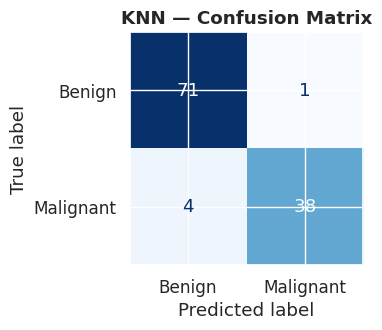

In [26]:
knn_model, knn_pred = evaluate(
    'KNN',
    KNeighborsClassifier(n_neighbors=best_k),
    X_train_sc, y_train, X_test_sc, y_test
)

---
## 8 · Algorithm 4 — K-Means Clustering (Unsupervised)

> K-Means is **unsupervised** — it has no access to labels during training.  
> We interpret the resulting clusters by comparing them to the true labels.

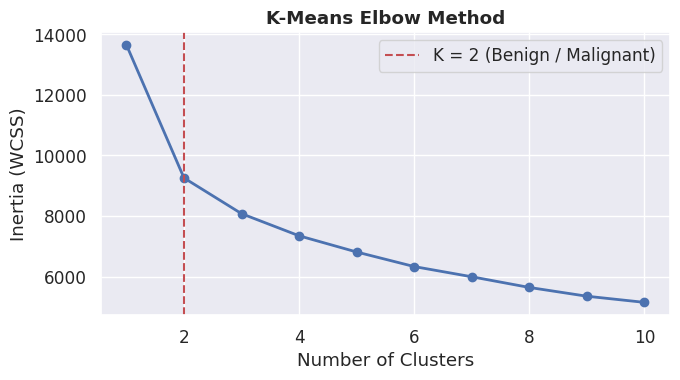

In [27]:
# ── Elbow method ─────────────────────────────────────────────────────────────
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_train_sc)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 11), inertias, marker='o', color='#4C72B0', linewidth=2)
ax.axvline(2, color='#C44E52', linestyle='--', label='K = 2 (Benign / Malignant)')
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('Inertia (WCSS)')
ax.set_title('K-Means Elbow Method', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


══════════════════════  K-Means (K=2)  ══════════════════════
              precision    recall  f1-score   support

      Benign       0.88      0.96      0.92        72
   Malignant       0.92      0.79      0.85        42

    accuracy                           0.89       114
   macro avg       0.90      0.87      0.88       114
weighted avg       0.90      0.89      0.89       114



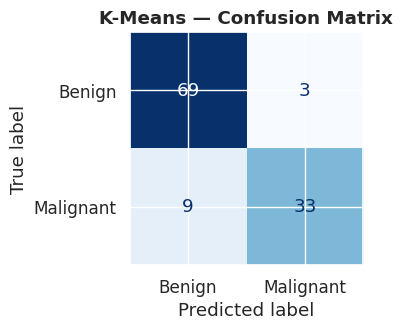

In [28]:
# ── Fit K-Means with K=2 ─────────────────────────────────────────────────────
km_model = KMeans(n_clusters=2, random_state=SEED, n_init=10)
km_model.fit(X_train_sc)

km_labels_test = km_model.predict(X_test_sc)

# Align cluster IDs to class labels (cluster 0 may correspond to Malignant)
# Compare the most frequent label in each cluster vs true labels
from scipy.stats import mode
aligned = np.zeros_like(km_labels_test)
for cluster_id in np.unique(km_labels_test):
    mask = km_labels_test == cluster_id
    most_common = mode(y_test.values[mask], keepdims=True).mode[0]
    aligned[mask] = most_common

km_acc  = accuracy_score(y_test, aligned)
km_prec = precision_score(y_test, aligned, zero_division=0)
km_rec  = recall_score(y_test, aligned, zero_division=0)
km_f1   = f1_score(y_test, aligned, zero_division=0)

results['K-Means'] = {'Accuracy': km_acc, 'Precision': km_prec,
                      'Recall': km_rec, 'F1': km_f1,
                      'ROC-AUC': np.nan, 'CV-Accuracy': np.nan}

print(f'\n══════════════════════  K-Means (K=2)  ══════════════════════')
print(classification_report(y_test, aligned, target_names=['Benign','Malignant']))

fig, ax = plt.subplots(figsize=(4, 3.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, aligned, display_labels=['Benign','Malignant'],
    colorbar=False, ax=ax, cmap='Blues'
)
ax.set_title('K-Means — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

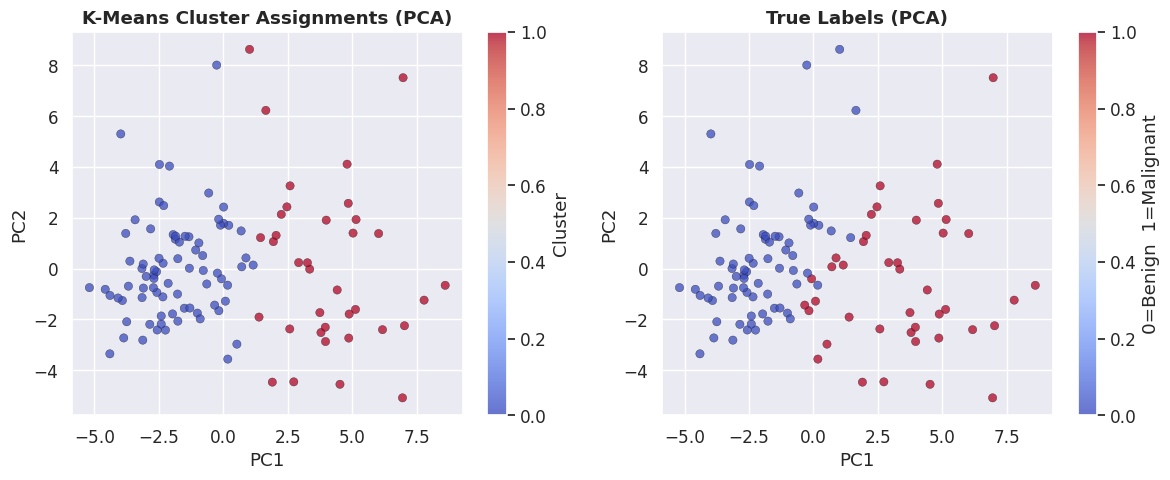

Variance explained by PC1+PC2: 63.0%


In [29]:
# ── PCA 2D cluster visualisation ─────────────────────────────────────────────
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_test_sc)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# K-Means clusters
scatter0 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=km_labels_test,
                            cmap='coolwarm', alpha=0.75, edgecolors='k', linewidths=0.3)
axes[0].set_title('K-Means Cluster Assignments (PCA)', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(scatter0, ax=axes[0], label='Cluster')

# True labels
scatter1 = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=y_test.values,
                            cmap='coolwarm', alpha=0.75, edgecolors='k', linewidths=0.3)
axes[1].set_title('True Labels (PCA)', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[1], label='0=Benign  1=Malignant')

plt.tight_layout()
plt.show()
print(f'Variance explained by PC1+PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%')

---
## 9 · Algorithm 5 — Decision Tree (ID3 — Information Gain / Entropy)

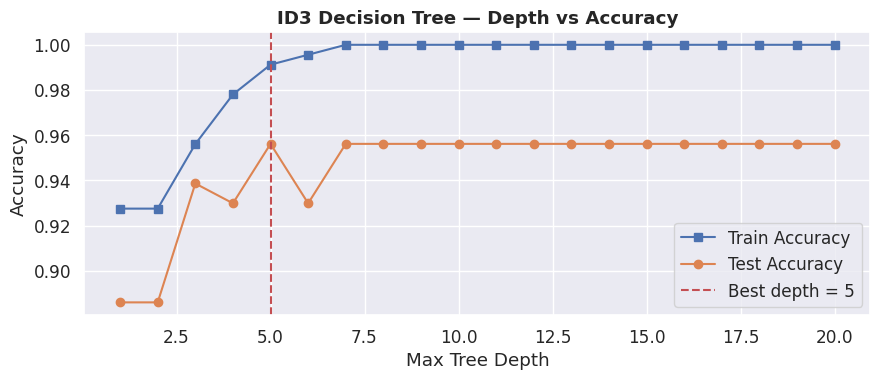

Best depth: 5  |  Test Accuracy: 0.9561


In [30]:
# ID3 uses entropy as the splitting criterion
# Scikit-learn's criterion='entropy' implements the ID3 splitting rule

# ── Depth tuning ──────────────────────────────────────────────────────────────
depths      = range(1, 21)
train_accs  = []
test_accs   = []

for d in depths:
    dt = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=SEED)
    dt.fit(X_train_sc, y_train)
    train_accs.append(accuracy_score(y_train, dt.predict(X_train_sc)))
    test_accs.append(accuracy_score(y_test,  dt.predict(X_test_sc)))

best_depth = depths[np.argmax(test_accs)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(depths), train_accs, marker='s', label='Train Accuracy', color='#4C72B0')
ax.plot(list(depths), test_accs,  marker='o', label='Test Accuracy',  color='#DD8452')
ax.axvline(best_depth, color='#C44E52', linestyle='--', label=f'Best depth = {best_depth}')
ax.set_xlabel('Max Tree Depth')
ax.set_ylabel('Accuracy')
ax.set_title('ID3 Decision Tree — Depth vs Accuracy', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Best depth: {best_depth}  |  Test Accuracy: {max(test_accs):.4f}')


══════════════════════  Decision Tree (ID3)  ══════════════════════
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

  ROC-AUC   : 0.9448
  CV-Acc(5) : 0.9341


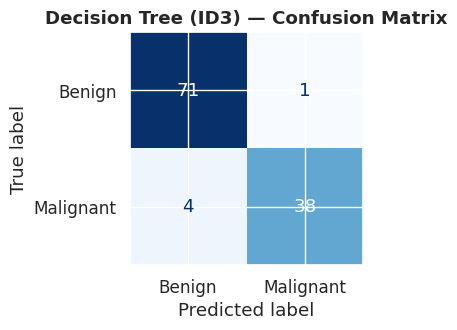

In [31]:
dt_model, dt_pred = evaluate(
    'Decision Tree (ID3)',
    DecisionTreeClassifier(criterion='entropy', max_depth=best_depth, random_state=SEED),
    X_train_sc, y_train, X_test_sc, y_test
)

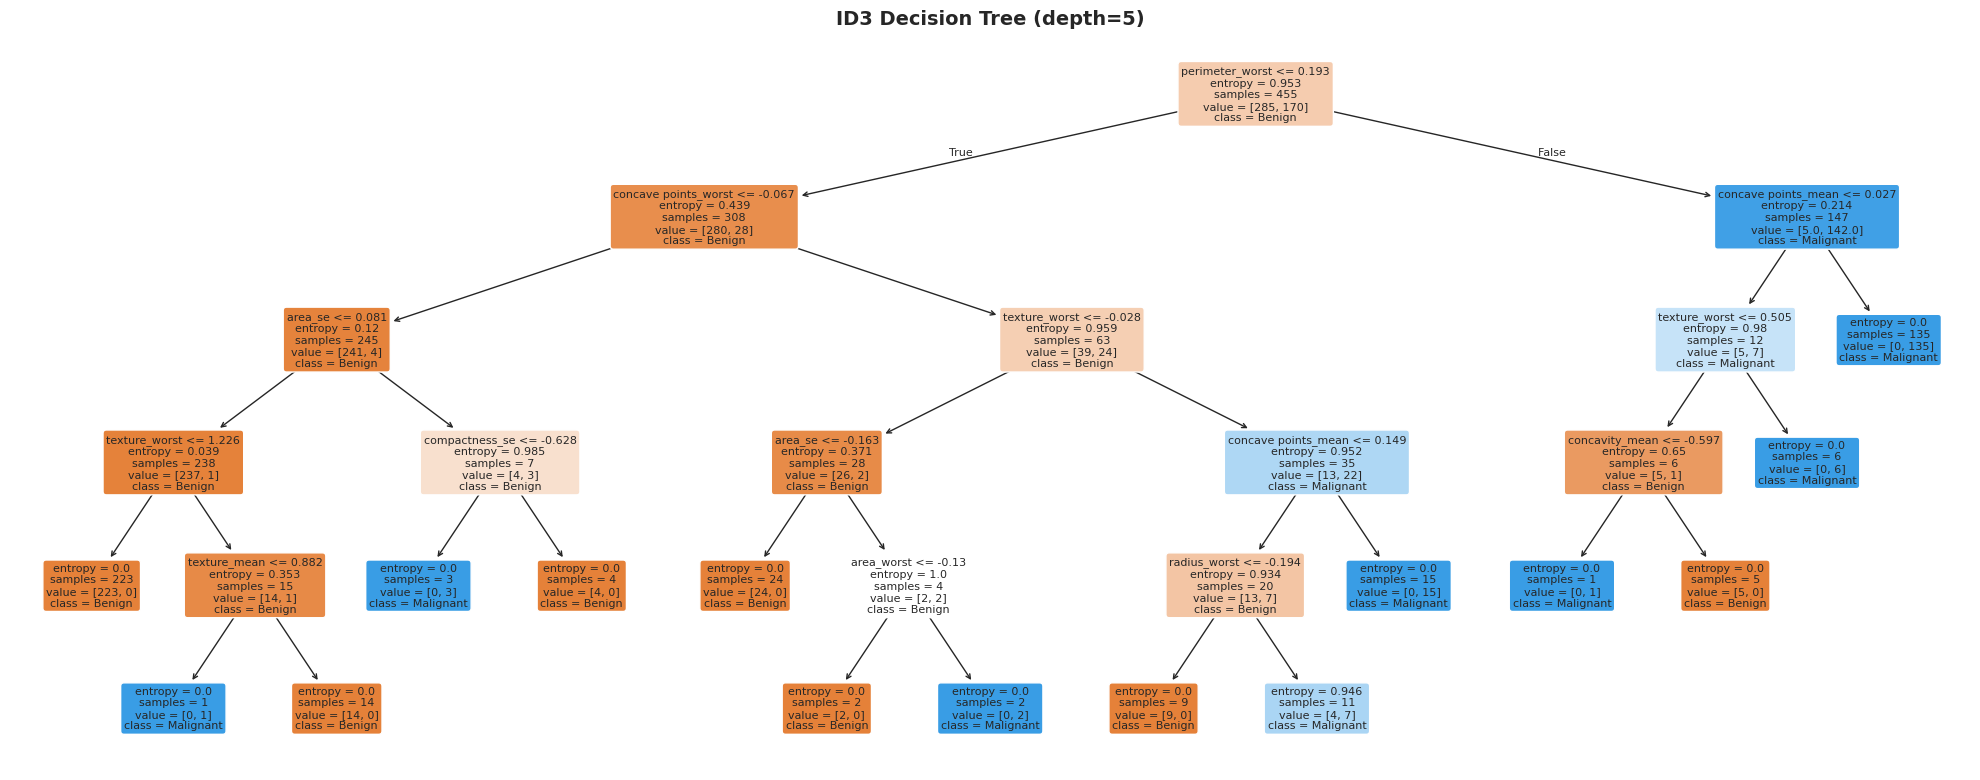

In [32]:
# ── Tree visualisation ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=X.columns.tolist(),
    class_names=['Benign', 'Malignant'],
    filled=True, rounded=True, impurity=True,
    fontsize=8, ax=ax
)
ax.set_title(f'ID3 Decision Tree (depth={best_depth})', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

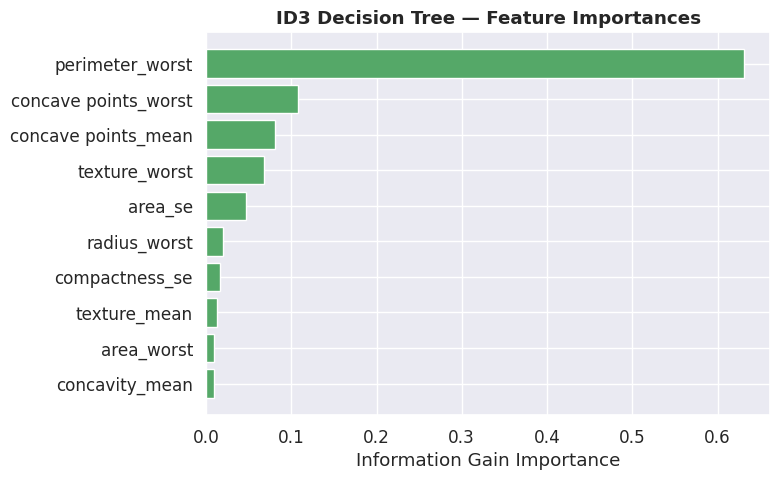

In [33]:
# ── Feature importance ────────────────────────────────────────────────────────
imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': dt_model.feature_importances_})
imp_df = imp_df[imp_df['Importance'] > 0].sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df['Feature'], imp_df['Importance'], color='#55A868')
ax.set_title('ID3 Decision Tree — Feature Importances', fontweight='bold')
ax.set_xlabel('Information Gain Importance')
plt.tight_layout()
plt.show()

---
## 10 · ROC Curves — Supervised Classifiers

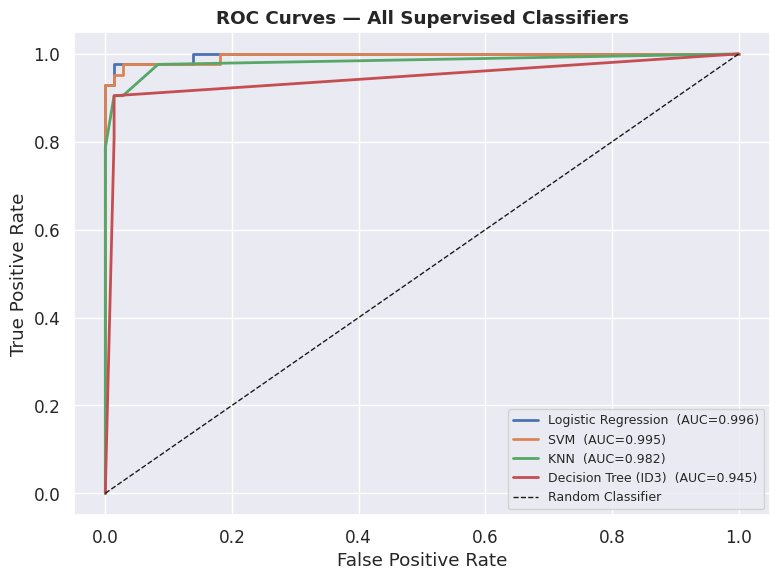

In [34]:
fig, ax = plt.subplots(figsize=(8, 6))

supervised = [
    ('Logistic Regression', lr_model),
    ('SVM',                 svm_model),
    ('KNN',                 knn_model),
    ('Decision Tree (ID3)', dt_model),
]

for (label, model), color in zip(supervised, COLORS):
    proba = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{label}  (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Supervised Classifiers', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

---
## 11 · Final Comparison

In [35]:
# ── Metrics table ─────────────────────────────────────────────────────────────
metrics_df = pd.DataFrame(results).T.round(4)
metrics_df = metrics_df.sort_values('Accuracy', ascending=False)

print('\n═══════════════  Model Comparison  ═══════════════')
display(metrics_df.style
        .format(na_rep='N/A', precision=4)
        .background_gradient(cmap='RdYlGn', subset=['Accuracy','F1','ROC-AUC'])
        .set_caption('Higher is better for all metrics'))


═══════════════  Model Comparison  ═══════════════


,Accuracy,Precision,Recall,F1,ROC-AUC,CV-Accuracy
SVM,0.9737,1.0000,0.9286,0.9630,0.9947,0.9758
Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9960,0.9714
KNN,0.9561,0.9744,0.9048,0.9383,0.9823,0.9626
Decision Tree (ID3),0.9561,0.9744,0.9048,0.9383,0.9448,0.9341
K-Means,0.8947,0.9167,0.7857,0.8462,N/A,N/A


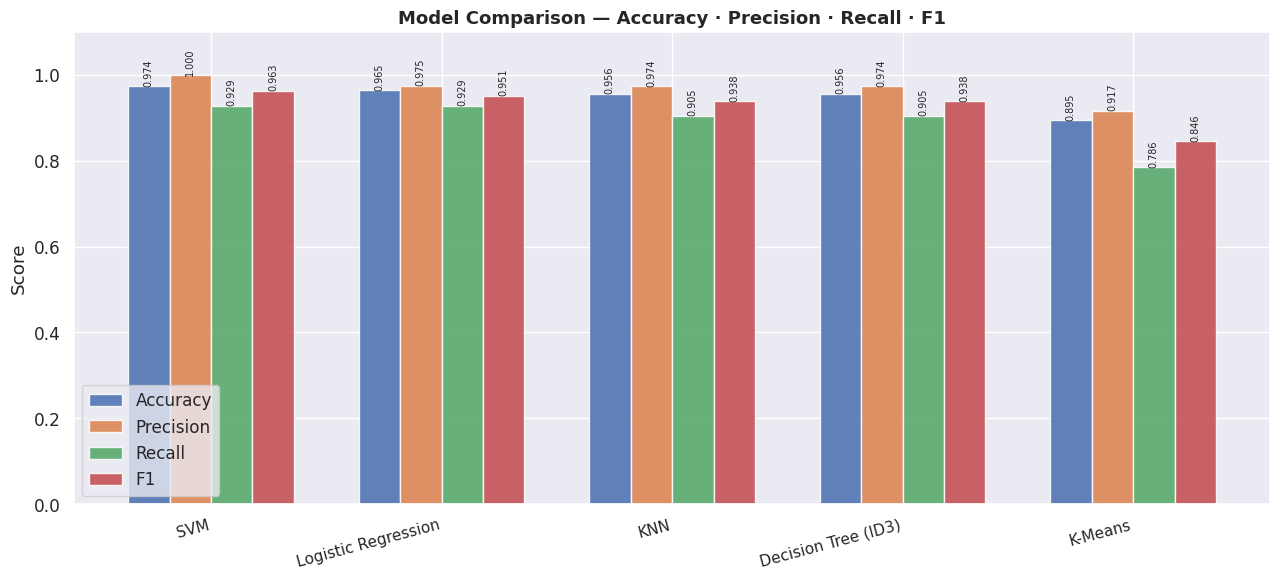

In [36]:
# ── Grouped bar chart ─────────────────────────────────────────────────────────
plot_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
plot_df = metrics_df[plot_metrics].copy()

fig, ax = plt.subplots(figsize=(13, 6))
x       = np.arange(len(plot_df))
width   = 0.18
offsets = np.linspace(-1.5*width, 1.5*width, 4)

for i, (metric, color) in enumerate(zip(plot_metrics, COLORS)):
    bars = ax.bar(x + offsets[i], plot_df[metric], width, label=metric, color=color, alpha=0.88)
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
                    f'{h:.3f}', ha='center', fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=15, ha='right', fontsize=11)
ax.set_ylim(0, 1.10)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy · Precision · Recall · F1', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

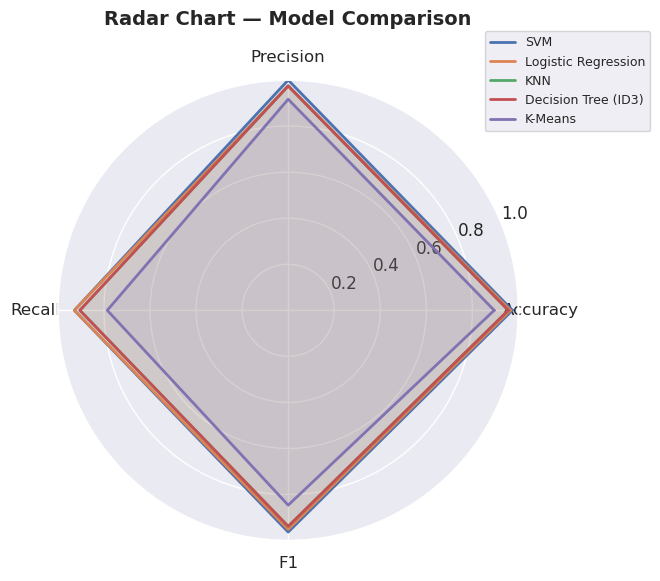

In [37]:
# ── Radar chart ───────────────────────────────────────────────────────────────
radar_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
radar_df      = metrics_df[radar_metrics].fillna(0)
labels        = radar_metrics + [radar_metrics[0]]   # close the polygon
angles        = np.linspace(0, 2*np.pi, len(radar_metrics), endpoint=False).tolist()
angles       += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
for (model_name, row), color in zip(radar_df.iterrows(), COLORS):
    values = row.tolist() + [row.iloc[0]]
    ax.plot(angles, values, label=model_name, color=color, linewidth=2)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_title('Radar Chart — Model Comparison', fontsize=14, fontweight='bold', pad=18)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.12), fontsize=9)
plt.tight_layout()
plt.show()

---
## 12 · Summary & Conclusions

| Algorithm | Type | Notes |
|---|---|---|
| **Logistic Regression** | Supervised / Linear | Fast, interpretable via coefficients, works well with scaled data |
| **SVM (RBF kernel)** | Supervised / Kernel | Excellent for high-dimensional data; best generalisation with correct kernel |
| **KNN** | Supervised / Non-parametric | Simple & effective; sensitive to distance scale → needs StandardScaler |
| **K-Means** | Unsupervised / Clustering | No label info used; performance reflects natural separability of the classes |
| **Decision Tree (ID3)** | Supervised / Rule-based | Highly interpretable tree; uses entropy/information gain; prone to over-fitting at high depth |

**Key takeaways:**
- SVM with the RBF kernel typically achieves the highest AUC on this dataset due to its margin maximisation objective.
- Logistic Regression is a strong baseline and lets us inspect each feature's positive/negative contribution.
- KNN performance is very sensitive to the choice of K — always tune it.
- K-Means cannot use label information, so its classification-style accuracy is limited, but the PCA plot confirms that the two classes **are** naturally separable in feature space.
- The ID3 tree provides fully human-readable rules, making it ideal when explainability is required in a medical context.
